In [1]:
import os
print(os.getcwd())


/home/jupyter-ipsita


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd 
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import splprep, splev, interp1d
from scipy.spatial.distance import euclidean
from ast import literal_eval
from scipy.spatial import cKDTree
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import Rbf
import matplotlib.pyplot as plt
import wellpathpy as wpp
import xarray as xr
import lasio
from segysak.segy import segy_loader
from tqdm import tqdm
import segyio
from scipy.ndimage import gaussian_filter
# Binary header keys
from segyio import BinField as bf


In [2]:
# === Step 1: Load checkshot-derived velocity function ===
checkshot_path = "/Users/ipsitabhar/Downloads/Tutorial/Wells/Cshots.txt"
df = pd.read_csv(checkshot_path, sep="\t", header=None,
                 names=["Well","TVDSS","TWT","X","Y","Vavg"])

In [3]:
# --- Fit polynomial background trend ---
z = df["TVDSS"].values
v = df["Vavg"].values
coeffs = np.polyfit(z, v, deg=2)
df["Residual"] = v - np.polyval(coeffs, z)

In [4]:
# Fit RBF interpolator over residuals
rbf = Rbf(df["X"], df["Y"], df["TVDSS"], df["Residual"], function="linear", smooth=500)

In [5]:
Full_3D_path2 = pathlib.Path("/Users/ipsitabhar/Downloads/Tutorial/Seismic_Depth/BN_Depth_Seismic.sgy")
ds = xr.open_dataset(
    Full_3D_path2,
    dim_byte_fields={"iline": 189, "xline": 193},   # ✅ Inline & crossline
    extra_byte_fields={"cdp_x": 181, "cdp_y": 185},   # ✅ X & Y coords
)
ds.segysak.scale_coords()


Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]


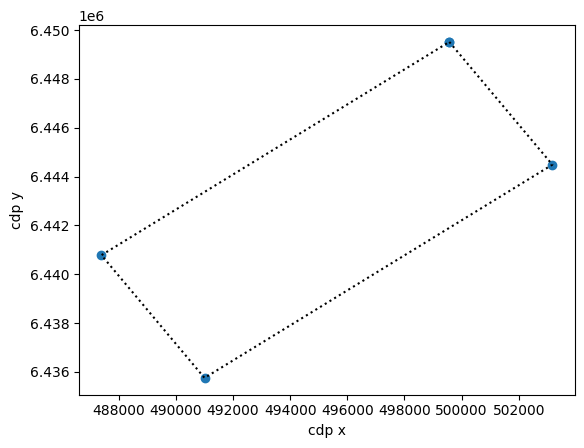

In [6]:
ax = ds.segysak.plot_bounds()

In [7]:
# Load well data
well_df = pd.read_csv(
    "/Users/ipsitabhar/Downloads/Tutorial/Wells/well_locations.txt", 
    sep="\t"
)
x = well_df["X"].values
y = well_df["Y"].values
names = well_df["Nickname"].values

In [12]:
# Check the shape of the 'data' variable directly
print(ds['data'].shape)
print(ds)

(151, 496, 751)
<xarray.Dataset> Size: 226MB
Dimensions:  (iline: 151, xline: 496, samples: 751)
Coordinates:
  * iline    (iline) int16 302B 1 2 3 4 5 6 7 8 ... 145 146 147 148 149 150 151
  * xline    (xline) int16 992B 1 2 3 4 5 6 7 8 ... 490 491 492 493 494 495 496
  * samples  (samples) float32 3kB 0.0 4.0 8.0 ... 2.992e+03 2.996e+03 3e+03
Data variables:
    cdp_x    (iline, xline) float64 599kB 4.996e+05 4.996e+05 ... 4.91e+05
    cdp_y    (iline, xline) float64 599kB 6.45e+06 6.45e+06 ... 6.436e+06
    data     (iline, xline, samples) float32 225MB ...
Attributes:
    seisnc:   {"coord_scalar": -10.0, "coord_scaled": true}


**Plotting wells on seismic survey**

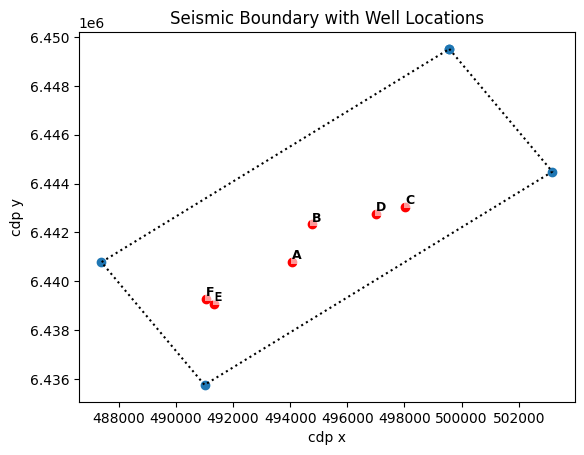

In [8]:
# Plot the seismic boundary
ax = ds.segysak.plot_bounds()

# Overlay wells as red circles
ax.plot(x, y, "ro", label="Wells")

# Add text labels for each well
for xi, yi, label in zip(x, y, names):
    ax.text(
        xi, yi, label, 
        fontsize=9, fontweight="bold",
        color="black", ha="left", va="bottom",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1)
    )

ax.set_title("Seismic Boundary with Well Locations")
plt.show()

In [10]:
# --- Output velocity cube (same shape as seismic) ---
n_il, n_xl, n_samp = ds.dims["iline"], ds.dims["xline"], ds.dims["samples"]
vel_cube = np.zeros((n_il, n_xl, n_samp), dtype=np.float32) # number of time or depth samples per trace (vertical resolution).

/var/folders/vs/vdnzm1dx3mx67h7qv7k7h69m0000gn/T/ipykernel_81256/2078505514.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_il, n_xl, n_samp = ds.dims["iline"], ds.dims["xline"], ds.dims["samples"]


In [11]:
# Depth/time axis from SEGY
z_axis = ds.coords["samples"].values  # usually in ms
# Convert to depth if needed; here assuming ms ~ depth index
z_axis = z_axis  # keep as-is

**To verify our Velocity Model for Time-Depth Conversion**

In [12]:
def check_well_honor(df, rbf, coeffs, alpha=1.0, wellname="011/30-05"):
    # Extract well data
    df_well = df[df["Well"] == wellname]
    wx, wy = df_well["X"].iloc[0], df_well["Y"].iloc[0]
    wz = df_well["TVDSS"].values
    v_well = df_well["Vavg"].values

    # Interpolate residuals at EXACT well depths
    res_interp = rbf(np.full_like(wz, wx),
                     np.full_like(wz, wy),
                     wz)

    # Reconstruct velocities
    v_interp = np.polyval(coeffs, wz) + alpha * res_interp

    # Compare with actual well
    misfit = v_interp - v_well
    print(f"Well {wellname}: max misfit = {np.abs(misfit).max():.3f} m/s, RMS misfit = {np.sqrt(np.mean(misfit**2)):.3f} m/s")

    return wz, v_well, v_interp

Well 11/30-_5: max misfit = 129.032 m/s, RMS misfit = 67.142 m/s


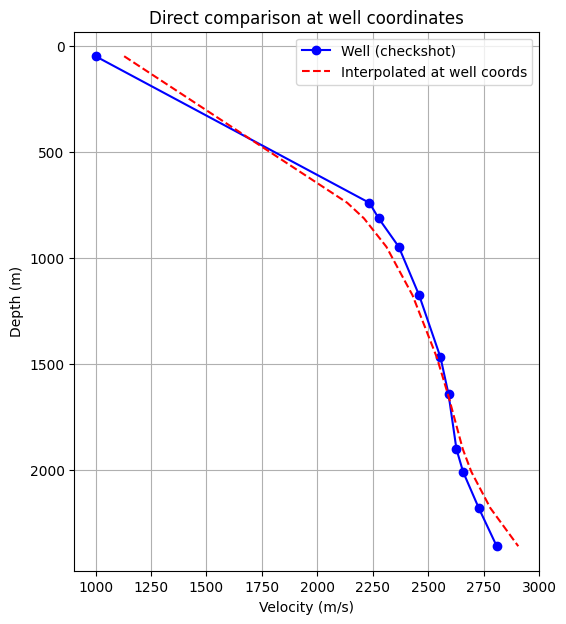

In [13]:
wz, v_well, v_interp = check_well_honor(df, rbf, coeffs, alpha=1, wellname="11/30-_5")

import matplotlib.pyplot as plt
plt.figure(figsize=(6,7))
plt.plot(v_well, wz, "bo-", label="Well (checkshot)")
plt.plot(v_interp, wz, "r--", label="Interpolated at well coords")
plt.gca().invert_yaxis()
plt.xlabel("Velocity (m/s)")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid(True)
plt.title("Direct comparison at well coordinates")
plt.show()

In [14]:
def get_interpolated_well_values(df, rbf, coeffs, alpha=1.0, wellname="11/30-_05"):
    # Extract well data
    df_well = df[df["Well"] == wellname]
    wx, wy = df_well["X"].iloc[0], df_well["Y"].iloc[0]
    wz = df_well["TVDSS"].values
    v_well = df_well["Vavg"].values

    # Interpolated residuals at EXACT well depths
    res_interp = rbf(np.full_like(wz, wx),
                     np.full_like(wz, wy),
                     wz)

    # Reconstruct interpolated velocity
    v_interp = np.polyval(coeffs, wz) + alpha * res_interp

    return wz, v_well, v_interp

In [15]:
wz, v_well, v_interp = get_interpolated_well_values(df, rbf, coeffs, alpha=1, wellname="11/30-_5")

print("Depths (m):", wz.tolist())
print("Checkshot velocities (blue):", v_well.tolist())
print("Interpolated velocities (red):", v_interp.tolist())

Depths (m): [49.6824, 740.664, 813.816, 947.928, 1176.528, 1469.136, 1642.872, 1901.952, 2008.632, 2179.32, 2359.152]
Checkshot velocities (blue): [1000.0, 2234.280543, 2276.408392, 2366.861423, 2458.783699, 2555.01913, 2591.280757, 2627.005525, 2656.920635, 2727.559449, 2808.514286]
Interpolated velocities (red): [1129.032440388021, 2134.764947487556, 2210.005748913512, 2311.1545234954438, 2429.0432096701243, 2538.4656296065095, 2588.4759641856017, 2655.6961533650856, 2694.198954955297, 2779.7277781258967, 2905.584885696766]


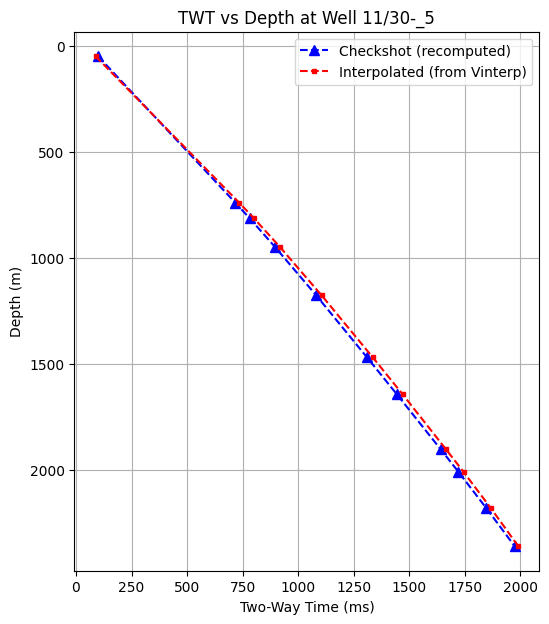

In [16]:
wellname="11/30-_5"
dz = np.diff(wz)
dz = np.insert(dz, 0, wz[0])  # prepend first depth as initial interval

    # --- Step 2: Use velocities at each depth point directly (no averaging) ---
    # Since dz and v have the same length now
dt_interp = 2 * dz / v_interp
dt_well = 2 * dz / v_well

    # --- Step 3: Cumulative sum to get TWT ---
twt_interp = np.cumsum(dt_interp) * 1000  # ms
twt_from_vwell = np.cumsum(dt_well) * 1000  # ms
#twt_diff= twt_from_vwell-twt_interp
    # --- Step 4: Plot ---
plt.figure(figsize=(6, 7))

    # Checkshot TWT from file (big blue circles)
#plt.plot(twt_from_vwell, wz, "bo-", markersize=8, label="Checkshot (from file)")

    # Checkshot TWT recomputed (blue triangles)
plt.plot(twt_from_vwell, wz, "b^--", markersize=7, label="Checkshot (recomputed)")

    # Interpolated velocities → TWT (smaller red squares)
plt.plot(twt_interp, wz, "rs--", markersize=3, label="Interpolated (from Vinterp)")


plt.gca().invert_yaxis()
plt.xlabel("Two-Way Time (ms)")
plt.ylabel("Depth (m)")
plt.title(f"TWT vs Depth at Well {wellname}")
plt.legend()
plt.grid(True)
plt.show()

**Trace by Trace interpolation**

In [17]:
alpha=1
for i, il in enumerate(tqdm(ds.iline.values, desc="Interpolating inlines")):
    for j, xl in enumerate(ds.xline.values):
        x = ds["cdp_x"].sel(iline=il, xline=xl).item()
        y = ds["cdp_y"].sel(iline=il, xline=xl).item()
        
        # Handle bad coordinates
        if np.isnan(x) or np.isnan(y) or (x == 0 and y == 0):
            # Find nearest valid coordinates
            for di in range(-5, 6):
                for dj in range(-5, 6):
                    if di == 0 and dj == 0:
                        continue
                    try:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < n_il and 0 <= nj < n_xl:
                            nx = ds["cdp_x"].isel(iline=ni, xline=nj).item()
                            ny = ds["cdp_y"].isel(iline=ni, xline=nj).item()
                            if not (np.isnan(nx) or np.isnan(ny) or (nx == 0 and ny == 0)):
                                x, y = nx, ny
                                break
                    except:
                        continue
                if not (np.isnan(x) or (x == 0 and y == 0)):
                    break
        
        # Compute velocity
        res_trace = rbf(np.full_like(z_axis, x),
                        np.full_like(z_axis, y),
                        z_axis)
        vel_trace = np.polyval(coeffs, z_axis) + alpha * res_trace
        vel_cube[i, j, :] = vel_trace

print("Velocity cube shape:", vel_cube.shape)


Interpolating inlines: 100%|██████████| 151/151 [00:20<00:00,  7.19it/s]

Velocity cube shape: (151, 496, 801)


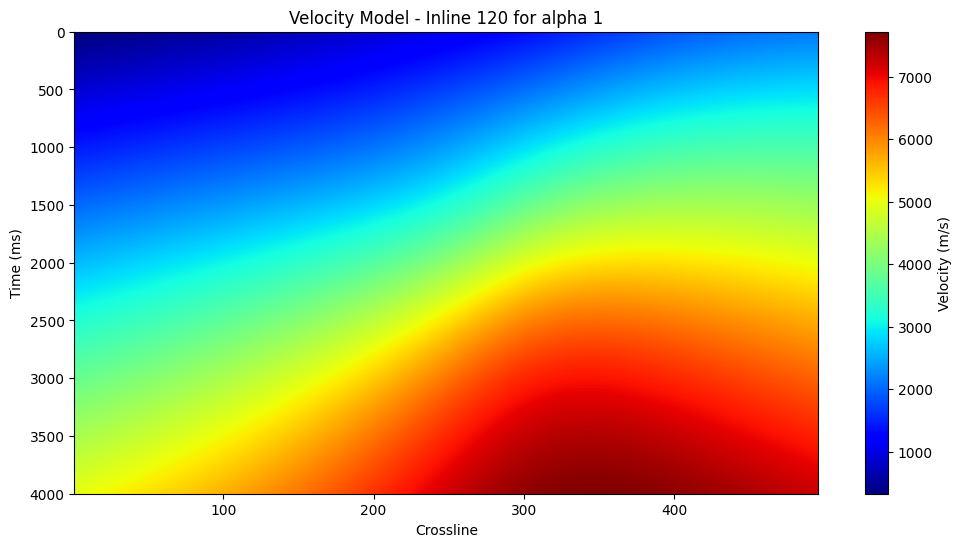

In [18]:
iline_val = 120

# Extract index of inline 1000
iline_idx = np.where(ds.iline.values == iline_val)[0][0]

# Extract slice from velocity cube
inline_slice = vel_cube[iline_idx, :, :]   # shape (xline, samples)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(
    inline_slice.T,
    extent=[ds.xline.values.min(), ds.xline.values.max(),
            ds.samples.values.max(), ds.samples.values.min()],
    cmap="jet", aspect="auto"
)
plt.colorbar(label="Velocity (m/s)")
plt.xlabel("Crossline")
plt.ylabel("Time (ms)")
plt.title(f"Velocity Model - Inline {iline_val} for alpha {alpha}")
plt.show()

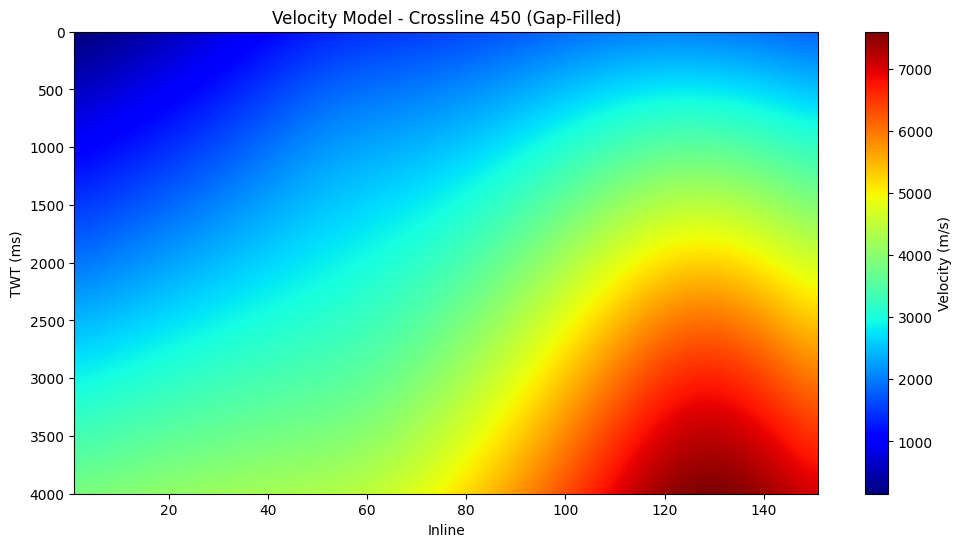

In [19]:
# === Step 3: Extract and interpolate crossline ===
xline_val = 450
xline_idx = np.where(ds.xline.values == xline_val)[0][0]
crossline_slice = vel_cube[:, xline_idx, :]

# Apply 2D Gaussian filter to smooth out gaps
crossline_filled = gaussian_filter(crossline_slice, sigma=(3, 1))

# === Step 4: Plot gap-filled crossline ===
plt.figure(figsize=(12, 6))
im = plt.imshow(
    crossline_filled.T,
    cmap="jet", aspect="auto",
    extent=[ds.iline.values.min(), ds.iline.values.max(),
            ds.samples.values.max(), ds.samples.values.min()]
)
plt.colorbar(im, label="Velocity (m/s)")
plt.xlabel("Inline")
plt.ylabel("TWT (ms)")
plt.title(f"Velocity Model - Crossline {xline_val} (Gap-Filled)")
plt.show()

In [20]:
input_sgy = "/Users/ipsitabhar/Downloads/Tutorial/Velocity_Cube/BN_Velocity.sgy"  # Path for the velocity cube exported from OpendTect

# Open SEG-Y to inspect
with segyio.open(input_sgy, "r", ignore_geometry=False) as f:
    n_traces = f.tracecount
    n_samples = f.samples.size
    print(f"Trace count: {n_traces}")
    print(f"Samples per trace: {n_samples}")
    print(f"Inline range: {f.ilines[0]} - {f.ilines[-1]}")
    print(f"Crossline range: {f.xlines[0]} - {f.xlines[-1]}")

    # Example: Read headers for the first trace
    header_example = f.header[0]
    print("Header keys:", header_example)

Trace count: 74896
Samples per trace: 751
Inline range: 1 - 151
Crossline range: 1 - 496
Header keys: {TRACE_SEQUENCE_LINE: 1, TRACE_SEQUENCE_FILE: 1, FieldRecord: 1, TraceNumber: 0, EnergySourcePoint: 0, CDP: 1, CDP_TRACE: 0, TraceIdentificationCode: 1, NSummedTraces: 0, NStackedTraces: 0, DataUse: 1, offset: 0, ReceiverGroupElevation: 0, SourceSurfaceElevation: 0, SourceDepth: 0, ReceiverDatumElevation: 0, SourceDatumElevation: 0, SourceWaterDepth: 0, GroupWaterDepth: 0, ElevationScalar: 0, SourceGroupScalar: -10, SourceX: 4995690, SourceY: 64495151, GroupX: 0, GroupY: 0, CoordinateUnits: 1, WeatheringVelocity: 0, SubWeatheringVelocity: 0, SourceUpholeTime: 0, GroupUpholeTime: 0, SourceStaticCorrection: 0, GroupStaticCorrection: 0, TotalStaticApplied: 0, LagTimeA: 0, LagTimeB: 0, DelayRecordingTime: 0, MuteTimeStart: 0, MuteTimeEND: 0, TRACE_SAMPLE_COUNT: 751, TRACE_SAMPLE_INTERVAL: 4000, GainType: 0, InstrumentGainConstant: 0, InstrumentInitialGain: 0, Correlated: 0, SweepFrequencyS